# MICA vs. Baselines — Statistical Analysis

12-entry benchmark (EMDB IDs), 4 methods (MICA, ModelAngelo, CryoAtom,
EModelX(+AF)). n=12 per method, paired by entry (same 12 entries, all
4 methods run on each) -> repeated-measures design -> non-parametric
tests (Friedman omnibus, Wilcoxon signed-rank post-hoc), per the
project's statistics-rigor standard (small n, no normality assumption).

## Metrics — mapped against the MICA paper's own protocol

The MICA paper (Gyawali, Dhakal & Cheng, *Communications Chemistry*
2025) benchmarks on **6 metrics**: TM-score, Ca match, Ca quality
score, aligned Ca length, sequence identity, sequence match. We
reproduce **5 of the 6 exactly**, using the same tools the paper
itself names in its Methods section:

| Paper's metric | Paper's tool | Our column | Reproduced? |
|---|---|---|---|
| TM-score | US-align | `TM_score_ref` | Yes — same tool |
| Aligned Ca length | US-align | `Aligned_length` | Yes — same tool |
| Sequence identity | US-align | `Seq_ID` | Yes — same tool |
| Ca match | Phenix `chain_comparison` | `Ca_match` (renamed from `Pct_found`) | Yes — same tool, same field (% of residues found close) |
| Sequence match | Phenix `chain_comparison` | `Seq_match_pct` | Yes — same tool, same field |
| Ca quality score | (custom, paper-defined) | — | **Not reproduced** — see note below |

**Ca quality score gap**: the paper defines this only in prose
("precision refers to the Ca match score, and coverage is the ratio
of predicted Ca atoms to true residues") with no equation given — the
exact combination formula (product? harmonic mean? weighted sum?) is
not disclosed anywhere in the main text, Methods, or the equations
provided (Eq. 1-3 are all for the training loss, not evaluation
metrics). We are not guessing at a formula we can't verify — this is
flagged as a reproducibility gap in the paper's own Methods section,
not something we're omitting out of laziness.

**Metric we added beyond the paper's protocol — `CA_score`**: Phenix
`chain_comparison`'s own internal "CA SCORE" column
(`= fraction_close / RMSD_of_close_residues`). **Important: despite
the similar name, this is NOT the same as the paper's "Ca quality
score"** — the paper's version uses only Ca match (closeness
threshold) and coverage, no RMSD magnitude at all; Phenix's own
internal field divides directly by RMSD. We introduced this
additional metric specifically because none of the paper's 6 metrics
directly penalize *how close* a correctly-placed atom is (TM-score
tolerates global superposition; Ca match only checks a binary
<3A threshold, not magnitude within that threshold). This additional
analysis is what surfaced the real finding that MICA's un-refined
output (no `phenix.real_space_refine` step was run — see Stage 20/21
in CLAUDE.md) has a genuine, consistent RMSD/placement-precision gap
vs. ModelAngelo/CryoAtom that none of the paper's own metrics would
have caught. Reported in its own clearly-separated section below, not
mixed into the paper-reproduction results.

**Docking-coverage stratification** (Stage 13i decision): MICA's
domain-fusion step only engages when Phenix `dock_in_map` found at
least one genuine (CC>=0.2) docking hit for that entry; otherwise MICA
falls back to map-only prediction. 9/12 entries got domain-fusion,
3/12 (`76934`, `64362`, `73799`) are map-only. Reported as a stratum,
not excluded.

**Known data point**: `65506/EModelX` has CA_score=0.00/RMSD=0.00 in
chain_comparison despite TM-score 0.94-0.997 in US-align — confirmed
genuine (not a parsing bug): the EModelX output for this one entry
sits in a different coordinate frame than the ground truth, which
`chain_comparison` (no superposition step) cannot handle but US-align
(always superposes) can. Kept in both analyses as real data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

RNG_SEED = 42
N_BOOT = 10000
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

METHOD_ORDER = ["MICA", "ModelAngelo", "CryoAtom", "EModelX"]
DISPLAY_NAME = {"MICA": "MICA", "ModelAngelo": "ModAng", "CryoAtom": "CryoAtom", "EModelX": "EModelX"}  # plot/axis labels only; data values stay as METHOD_ORDER
MAP_ONLY_ENTRIES = {"76934", "64362", "73799"}  # no genuine CC>=0.2 docking hit -> no domain-fusion


## Dataset characteristics — stratified-random sampling design

The 12 benchmark entries were selected by stratified random sampling
over a 3x4 grid (protein size: small/medium/large x map resolution:
near-atomic/high/mid/low), fixed seed 42, after excluding any
candidate with >=25% sequence identity to MICA's disclosed training
set (MMSeqs2 screen). This section visualizes that design directly
from `shortlist_12_v3_stratified_random.csv` — one point per entry, to
confirm actual coverage (not just the intended design) before any
results are interpreted.

In [2]:
dataset = pd.read_csv("../data/benchmark/shortlist_12_v3_stratified_random.csv")
SIZE_ORDER = ["small", "medium", "large"]
RES_ORDER = ["near-atomic (<2.2)", "high (2.2-2.8)", "mid (2.8-3.4)", "low (3.4-4.0)"]
dataset["size_bin"] = pd.Categorical(dataset["size_bin"], categories=SIZE_ORDER, ordered=True)
dataset["res_bin"] = pd.Categorical(dataset["res_bin"], categories=RES_ORDER, ordered=True)
dataset[["pdb_id", "emdb_ids", "size_bin", "res_bin", "resolution", "residue_count", "chain_count"]]


,pdb_id,emdb_ids,size_bin,res_bin,resolution,residue_count,chain_count
0,38PA,EMD-79027,large,high (2.2-2.8),2.70,2476,4
1,9XTI,EMD-67233,large,low (3.4-4.0),3.73,3382,4
2,9Z49,EMD-73799,large,mid (2.8-3.4),3.08,3776,12
3,9UNU,EMD-64362,large,near-atomic (<2.2),2.18,2299,11
4,10AC,EMD-75023,medium,high (2.2-2.8),2.47,1206,3
5,13BV,EMD-76934,medium,low (3.4-4.0),3.77,1976,4
6,9OM7,EMD-70609,medium,mid (2.8-3.4),3.30,1573,6
7,9PXL,EMD-71973,medium,near-atomic (<2.2),2.11,2044,8
8,9UWY,EMD-64568,small,high (2.2-2.8),2.48,966,3
9,9K88,EMD-62164,small,low (3.4-4.0),3.93,371,1


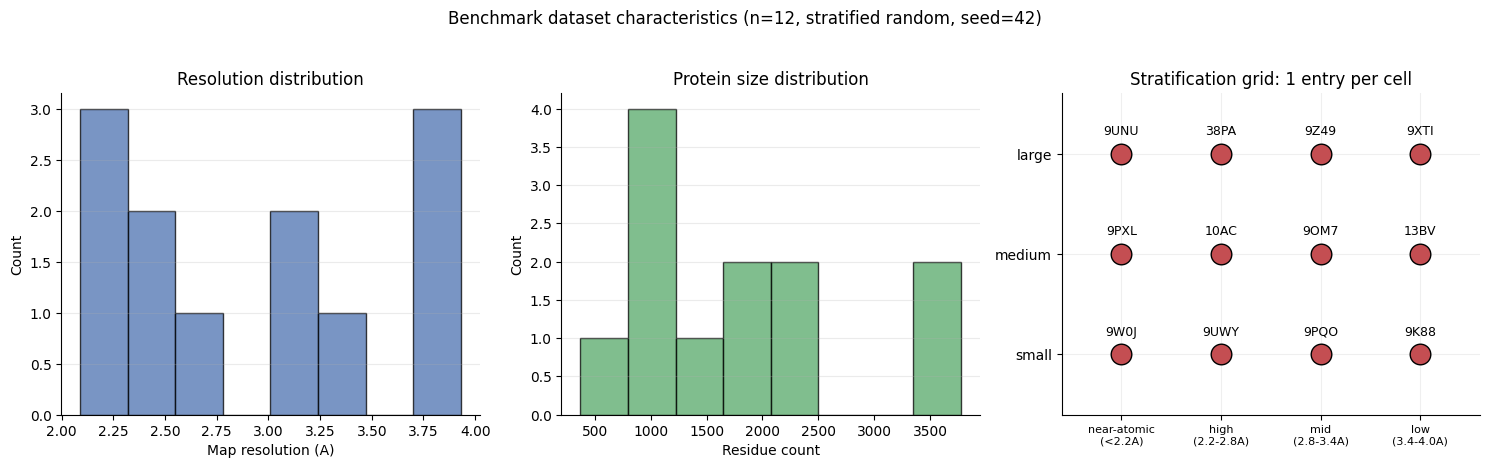

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: resolution distribution
axes[0].hist(dataset["resolution"], bins=8, color="#4C72B0", edgecolor="black", alpha=0.75)
axes[0].set_xlabel("Map resolution (A)")
axes[0].set_ylabel("Count")
axes[0].set_title("Resolution distribution")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", alpha=0.25)

# Panel 2: residue count (protein size) distribution
axes[1].hist(dataset["residue_count"], bins=8, color="#55A868", edgecolor="black", alpha=0.75)
axes[1].set_xlabel("Residue count")
axes[1].set_ylabel("Count")
axes[1].set_title("Protein size distribution")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", alpha=0.25)

# Panel 3: the stratification grid itself -- one point per cell, labeled
size_pos = {s: i for i, s in enumerate(SIZE_ORDER)}
res_pos = {r: i for i, r in enumerate(RES_ORDER)}
for _, row in dataset.iterrows():
    x = res_pos[row["res_bin"]]
    y = size_pos[row["size_bin"]]
    axes[2].scatter(x, y, s=220, color="#C44E52", edgecolor="black", zorder=3)
    axes[2].annotate(row["pdb_id"], (x, y), textcoords="offset points",
                      xytext=(0, 14), ha="center", fontsize=9)
axes[2].set_xticks(range(len(RES_ORDER)))
axes[2].set_xticklabels(["near-atomic\n(<2.2A)", "high\n(2.2-2.8A)", "mid\n(2.8-3.4A)", "low\n(3.4-4.0A)"],
                         fontsize=8)
axes[2].set_yticks(range(len(SIZE_ORDER)))
axes[2].set_yticklabels(SIZE_ORDER)
axes[2].set_xlim(-0.6, len(RES_ORDER) - 0.4)
axes[2].set_ylim(-0.6, len(SIZE_ORDER) - 0.4)
axes[2].set_title("Stratification grid: 1 entry per cell")
axes[2].grid(alpha=0.2)
axes[2].spines[["top", "right"]].set_visible(False)

fig.suptitle("Benchmark dataset characteristics (n=12, stratified random, seed=42)", y=1.03)
fig.tight_layout()
fig.savefig("../figures/dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
print(f"Resolution range: {dataset['resolution'].min():.2f}-{dataset['resolution'].max():.2f} A, "
      f"median {dataset['resolution'].median():.2f} A")
print(f"Residue count range: {dataset['residue_count'].min()}-{dataset['residue_count'].max()}, "
      f"median {dataset['residue_count'].median():.0f}")
print(f"Chain count range: {dataset['chain_count'].min()}-{dataset['chain_count'].max()}, "
      f"median {dataset['chain_count'].median():.0f}")
print(f"\nCells filled: {dataset.groupby(['size_bin','res_bin'], observed=True).size().sum()} / "
      f"{len(SIZE_ORDER) * len(RES_ORDER)} grid cells, "
      f"{dataset.groupby(['size_bin','res_bin'], observed=True).size().max()} max entries per cell")


Resolution range: 2.09-3.93 A, median 2.89 A
Residue count range: 371-3776, median 1774
Chain count range: 1-12, median 4

Cells filled: 12 / 12 grid cells, 1 max entries per cell


In [5]:
usalign = pd.read_csv("../data/evaluation/evaluation_usalign.csv", dtype={"emdb_num": str})
chaincmp = pd.read_csv("../data/evaluation/evaluation_chain_comparison.csv", dtype={"emdb_num": str})
chaincmp = chaincmp.rename(columns={"Pct_found": "Ca_match"})

df = usalign.merge(
    chaincmp, on=["emdb_num", "pdb_id", "method"], suffixes=("_usalign", "_chaincmp")
)
df["docking_coverage"] = np.where(
    df["emdb_num"].isin(MAP_ONLY_ENTRIES), "map-only", "domain-fusion"
)
df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)
df = df.sort_values(["emdb_num", "method"]).reset_index(drop=True)

assert df.shape[0] == 48, f"expected 48 rows, got {df.shape[0]}"
assert df[["error_usalign", "error_chaincmp"]].isna().all().all(), "unexpected eval errors present"
df.head(8)


,emdb_num,pdb_id,method,TM_score_ref,TM_score_query,RMSD_usalign,Seq_ID,Aligned_length,error_usalign,RMSD_chaincmp,...,Mixed,Ca_match,CA_score,Seq_match_pct,Seq_score,Mean_length,Fragments,Bad_connections,error_chaincmp,docking_coverage
0,62164,9k88,MICA,0.43855,0.78156,1.98,0.948,172,NaN,1.44,...,22,43.9,0.31,87.1,0.38,27.2,2,1,NaN,domain-fusion
1,62164,9k88,ModelAngelo,0.01613,0.67475,0.37,0.000,6,NaN,0.70,...,2,1.6,0.02,33.3,0.01,6.0,1,0,NaN,domain-fusion
2,62164,9k88,CryoAtom,0.39360,0.39976,2.27,0.924,157,NaN,1.15,...,26,82.7,0.72,86.3,0.71,16.2,11,7,NaN,domain-fusion
3,62164,9k88,EModelX,0.84670,0.87573,2.37,0.897,340,NaN,1.54,...,44,83.0,0.54,81.8,0.68,11.8,4,6,NaN,domain-fusion
4,64362,9unu,MICA,0.99649,0.97863,0.57,0.997,2294,NaN,0.53,...,15,99.7,1.89,99.6,0.99,163.6,11,9,NaN,map-only
5,64362,9unu,ModelAngelo,0.99049,0.95519,0.29,1.000,2278,NaN,0.26,...,15,99.2,3.86,99.8,0.99,175.4,21,7,NaN,map-only
6,64362,9unu,CryoAtom,0.99668,0.91110,0.25,1.000,2292,NaN,0.21,...,12,99.7,4.85,99.9,1.00,208.5,22,3,NaN,map-only
7,64362,9unu,EModelX,0.99331,0.98011,0.59,0.994,2287,NaN,0.55,...,16,99.4,1.79,99.3,0.99,152.4,12,8,NaN,map-only


## Per-protein summary table (centerpiece, per Stage 13i)

One row per entry, TM-score (the paper's primary/most-stringent
metric, ref-normalized) per method, plus docking-coverage stratum.

In [6]:
summary_table = df.pivot(index="emdb_num", columns="method", values="TM_score_ref")
summary_table = summary_table[METHOD_ORDER]
coverage = df.drop_duplicates("emdb_num").set_index("emdb_num")["docking_coverage"]
summary_table.insert(0, "docking_coverage", coverage)
summary_table = summary_table.sort_values(["docking_coverage", "emdb_num"])
summary_table


method,docking_coverage,MICA,ModelAngelo,CryoAtom,EModelX
emdb_num,,,,,
62164,domain-fusion,0.43855,0.01613,0.39360,0.84670
64568,domain-fusion,0.95733,0.96259,0.84022,0.99259
65506,domain-fusion,0.30693,0.98103,0.99533,0.93549
67233,domain-fusion,0.59327,0.11514,0.37798,0.60603
70609,domain-fusion,0.99771,0.99569,0.99852,0.83100
71787,domain-fusion,0.93055,0.92844,0.99837,0.78274
71973,domain-fusion,0.99652,0.99708,0.99714,0.99610
75023,domain-fusion,0.98067,0.99775,0.99953,0.99541
79027,domain-fusion,0.99730,0.84473,0.98597,0.95979


## Descriptive statistics — all 5 reproduced paper metrics + CA_score

Median with bootstrap 95% CI (plain percentile bootstrap, `N_BOOT=10000`,
seed=42) given n=12 and visibly skewed, non-normal distributions.

In [7]:
def bootstrap_median_ci(x, n_boot=N_BOOT, rng=rng, alpha=0.05):
    x = np.asarray(x, dtype=float)
    boot_medians = np.array([
        np.median(rng.choice(x, size=len(x), replace=True)) for _ in range(n_boot)
    ])
    lo, hi = np.percentile(boot_medians, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return np.median(x), lo, hi

PAPER_METRICS = [
    ("TM_score_ref", "TM-score (paper metric)"),
    ("Ca_match", "Ca match % (paper metric)"),
    ("Seq_match_pct", "Sequence match % (paper metric)"),
    ("Aligned_length", "Aligned Ca length (paper metric)"),
    ("Seq_ID", "Sequence identity (paper metric)"),
]
ADDED_METRICS = [("CA_score", "CA SCORE (our addition, NOT in paper)")]

rows = []
for metric_col, metric_name in PAPER_METRICS + ADDED_METRICS:
    for method in METHOD_ORDER:
        vals = df.loc[df["method"] == method, metric_col].dropna().values
        med, lo, hi = bootstrap_median_ci(vals)
        rows.append({"metric": metric_name, "method": method, "n": len(vals),
                      "median": round(med, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3)})
desc_table = pd.DataFrame(rows)
desc_table


,metric,method,n,median,ci_lo,ci_hi
0,TM-score (paper metric),MICA,12,0.966,0.724,0.997
1,TM-score (paper metric),ModelAngelo,12,0.969,0.697,0.993
2,TM-score (paper metric),CryoAtom,12,0.993,0.801,0.998
3,TM-score (paper metric),EModelX,12,0.948,0.807,0.993
4,Ca match % (paper metric),MICA,12,97.550,73.050,99.700
5,Ca match % (paper metric),ModelAngelo,12,97.050,85.650,99.500
6,Ca match % (paper metric),CryoAtom,12,99.550,97.650,99.750
7,Ca match % (paper metric),EModelX,12,97.050,81.350,99.750
8,Sequence match % (paper metric),MICA,12,99.050,92.350,99.550
9,Sequence match % (paper metric),ModelAngelo,12,98.900,96.750,99.900


## Omnibus test — Friedman, across all 5 reproduced paper metrics

Paired, non-parametric repeated-measures ANOVA analogue. H0: no
difference across the 4 methods, paired by entry. Effect size:
Kendall's W = chi2 / (n*(k-1)), 0=no agreement/no effect, 1=max.

In [8]:
def friedman_with_effect_size(df, metric_col, methods=METHOD_ORDER):
    wide = df.pivot(index="emdb_num", columns="method", values=metric_col)[methods].dropna()
    n, k = wide.shape
    stat, p = friedmanchisquare(*[wide[m].values for m in methods])
    kendalls_w = stat / (n * (k - 1))
    return {"metric": metric_col, "n_entries": n, "k_methods": k,
            "chi2": round(stat, 3), "df": k - 1, "p_value": round(p, 5),
            "kendalls_w": round(kendalls_w, 3)}, wide

friedman_results = []
wide_tables = {}
for metric_col, _ in PAPER_METRICS + ADDED_METRICS:
    result, wide = friedman_with_effect_size(df, metric_col)
    friedman_results.append(result)
    wide_tables[metric_col] = wide

friedman_df = pd.DataFrame(friedman_results)
friedman_df


,metric,n_entries,k_methods,chi2,df,p_value,kendalls_w
0,TM_score_ref,12,4,6.700,3,0.08210,0.186
1,Ca_match,12,4,10.091,3,0.01781,0.280
2,Seq_match_pct,12,4,12.566,3,0.00568,0.349
3,Aligned_length,12,4,6.963,3,0.07308,0.193
4,Seq_ID,12,4,3.791,3,0.28495,0.105
5,CA_score,12,4,27.555,3,0.00000,0.765


## Post-hoc pairwise — Wilcoxon signed-rank, MICA vs. each baseline

Run for every metric above (paper's 5 + our 1 addition), Holm-Bonferroni
corrected across the 3 pairwise comparisons within each metric. Effect
size: matched-pairs rank-biserial r = (W+ - W-) / (W+ + W-), range
[-1, 1]; sign = direction, magnitude = how consistent the gap is
across all 12 entries.

In [9]:
def rank_biserial_from_wilcoxon(x, y):
    diff = np.asarray(x) - np.asarray(y)
    diff_nz = diff[diff != 0]
    ranks = pd.Series(np.abs(diff_nz)).rank().values
    w_pos = ranks[diff_nz > 0].sum()
    w_neg = ranks[diff_nz < 0].sum()
    return (w_pos - w_neg) / (w_pos + w_neg) if (w_pos + w_neg) > 0 else np.nan

def pairwise_wilcoxon(wide, reference="MICA"):
    others = [m for m in wide.columns if m != reference]
    rows = []
    pvals = []
    for other in others:
        x, y = wide[reference].values, wide[other].values
        try:
            stat, p = wilcoxon(x, y)
        except ValueError:
            stat, p = np.nan, np.nan
        r = rank_biserial_from_wilcoxon(x, y)
        rows.append({"comparison": f"{reference} vs {other}", "W_stat": stat,
                      "p_raw": p, "rank_biserial_r": round(r, 3) if not np.isnan(r) else r})
        pvals.append(p)
    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    p_adj = np.full(len(pvals), np.nan)
    if valid:
        _, corrected, _, _ = multipletests([pvals[i] for i in valid], method="holm")
        for idx, c in zip(valid, corrected):
            p_adj[idx] = c
    for row, p in zip(rows, p_adj):
        row["p_holm"] = round(p, 5) if not np.isnan(p) else p
        row["p_raw"] = round(row["p_raw"], 5) if not np.isnan(row["p_raw"]) else row["p_raw"]
    return pd.DataFrame(rows)

posthoc_results = {}
for metric_col, metric_name in PAPER_METRICS + ADDED_METRICS:
    posthoc = pairwise_wilcoxon(wide_tables[metric_col])
    posthoc_results[metric_col] = posthoc
    print(f"=== {metric_name} ===")
    display(posthoc)
    print()


=== TM-score (paper metric) ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,MICA vs ModelAngelo,27.0,0.38037,0.308,1.0
1,MICA vs CryoAtom,37.0,0.90967,0.051,1.0
2,MICA vs EModelX,38.0,0.96973,0.026,1.0


=== Ca match % (paper metric) ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,MICA vs ModelAngelo,19.5,0.24902,0.409,0.49805
1,MICA vs CryoAtom,5.0,0.01074,-0.848,0.03223
2,MICA vs EModelX,26.5,0.59180,0.197,0.59180


=== Sequence match % (paper metric) ===


...

,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,MICA vs ModelAngelo,16.0,0.14746,0.515,0.44238
1,MICA vs CryoAtom,23.0,0.69531,0.164,1.00000
2,MICA vs EModelX,28.0,0.68359,0.152,1.00000


=== Sequence identity (paper metric) ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,MICA vs ModelAngelo,38.0,0.95264,-0.026,0.95264
1,MICA vs CryoAtom,13.5,0.31250,-0.400,0.93750
2,MICA vs EModelX,21.5,0.33105,0.348,0.93750


=== CA SCORE (our addition, NOT in paper) ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,MICA vs ModelAngelo,3.0,0.00244,-0.923,0.00488
1,MICA vs CryoAtom,0.0,0.00049,-1.000,0.00146
2,MICA vs EModelX,16.0,0.07422,0.590,0.07422


## Headline comparison — paper's metrics vs. our added CA_score

The point of building both: on every metric the paper itself reports,
does MICA's ranking vs. ModelAngelo/CryoAtom/EModelX match what the
paper claims? And does the additional CA_score metric reveal something
the paper's own protocol would not have caught?

In [10]:
headline_rows = []
for metric_col, metric_name in PAPER_METRICS + ADDED_METRICS:
    is_paper = metric_col != "CA_score"
    for _, row in posthoc_results[metric_col].iterrows():
        headline_rows.append({
            "metric": metric_name, "in_paper_protocol": is_paper,
            "comparison": row["comparison"], "p_holm": row["p_holm"],
            "significant": row["p_holm"] < 0.05 if pd.notna(row["p_holm"]) else None,
            "direction": "MICA lower" if row["rank_biserial_r"] < 0 else "MICA higher",
        })
headline_table = pd.DataFrame(headline_rows)
headline_table


,metric,in_paper_protocol,comparison,p_holm,significant,direction
0,TM-score (paper metric),True,MICA vs ModelAngelo,1.00000,False,MICA higher
1,TM-score (paper metric),True,MICA vs CryoAtom,1.00000,False,MICA higher
2,TM-score (paper metric),True,MICA vs EModelX,1.00000,False,MICA higher
3,Ca match % (paper metric),True,MICA vs ModelAngelo,0.49805,False,MICA higher
4,Ca match % (paper metric),True,MICA vs CryoAtom,0.03223,True,MICA lower
5,Ca match % (paper metric),True,MICA vs EModelX,0.59180,False,MICA higher
6,Sequence match % (paper metric),True,MICA vs ModelAngelo,0.44922,False,MICA lower
7,Sequence match % (paper metric),True,MICA vs CryoAtom,0.09668,False,MICA lower
8,Sequence match % (paper metric),True,MICA vs EModelX,0.44922,False,MICA higher
9,Aligned Ca length (paper metric),True,MICA vs ModelAngelo,0.44238,False,MICA higher


## Stratified comparison — domain-fusion (n=9) vs. map-only (n=3)

Descriptive only, on TM-score (the paper's primary metric). n=3 for
the map-only stratum is too small for a valid non-parametric test —
explicit scope boundary, not papered over with a meaningless test.

In [11]:
strat_rows = []
for coverage_group in ["domain-fusion", "map-only"]:
    sub = df[df["docking_coverage"] == coverage_group]
    for method in METHOD_ORDER:
        vals = sub.loc[sub["method"] == method, "TM_score_ref"].dropna().values
        strat_rows.append({
            "docking_coverage": coverage_group, "method": method, "n": len(vals),
            "median_TM": round(np.median(vals), 3) if len(vals) else np.nan,
            "IQR_TM": round(np.subtract(*np.percentile(vals, [75, 25])), 3) if len(vals) else np.nan,
        })
strat_table = pd.DataFrame(strat_rows)
strat_table


,docking_coverage,method,n,median_TM,IQR_TM
0,domain-fusion,MICA,9,0.957,0.403
1,domain-fusion,ModelAngelo,9,0.963,0.151
2,domain-fusion,CryoAtom,9,0.995,0.158
3,domain-fusion,EModelX,9,0.935,0.162
4,map-only,MICA,3,0.974,0.071
5,map-only,ModelAngelo,3,0.975,0.220
6,map-only,CryoAtom,3,0.992,0.117
7,map-only,EModelX,3,0.962,0.124


## Figure — TM-score by method, split by docking-coverage stratum

/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/2385325576.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/2385325576.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)


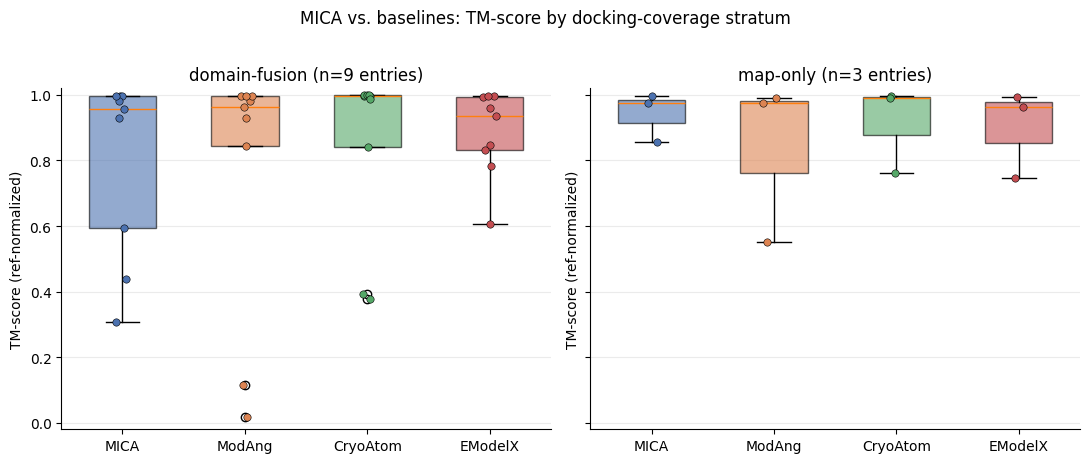

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
palette = {"MICA": "#4C72B0", "ModelAngelo": "#DD8452", "CryoAtom": "#55A868", "EModelX": "#C44E52"}

for ax, coverage_group in zip(axes, ["domain-fusion", "map-only"]):
    sub = df[df["docking_coverage"] == coverage_group]
    data = [sub.loc[sub["method"] == m, "TM_score_ref"].values for m in METHOD_ORDER]
    bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)
    for patch, m in zip(bp["boxes"], METHOD_ORDER):
        patch.set_facecolor(palette[m])
        patch.set_alpha(0.6)
    for i, m in enumerate(METHOD_ORDER, start=1):
        y = sub.loc[sub["method"] == m, "TM_score_ref"].values
        x = rng.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, color=palette[m], edgecolor="black", linewidth=0.4, zorder=3, s=28)
    n_entries = sub["emdb_num"].nunique()
    ax.set_title(f"{coverage_group} (n={n_entries} entries)")
    ax.set_ylabel("TM-score (ref-normalized)")
    ax.set_ylim(-0.02, 1.02)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("MICA vs. baselines: TM-score by docking-coverage stratum", y=1.02)
fig.tight_layout()
fig.savefig("../figures/tm_score_by_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure — all 6 metrics, boxplots not bar-of-means

Deliberately parallels the MICA paper's own Fig. 2/4 layout (6 panels,
one per metric, grouped by method) but uses **boxplots instead of
bar-of-means** -- with n=12 and visibly skewed distributions (established
above), a single averaged bar per method hides exactly the spread and
outliers that matter here; a boxplot (median line, IQR box, whisker
range, individual points) shows the full distribution the mean would
collapse away. `CA_score` is included as a 6th panel, explicitly
labeled as the metric added beyond the paper's protocol, consistent
with its treatment everywhere else in this analysis.

/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/3688081965.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/3688081965.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/3688081965.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  

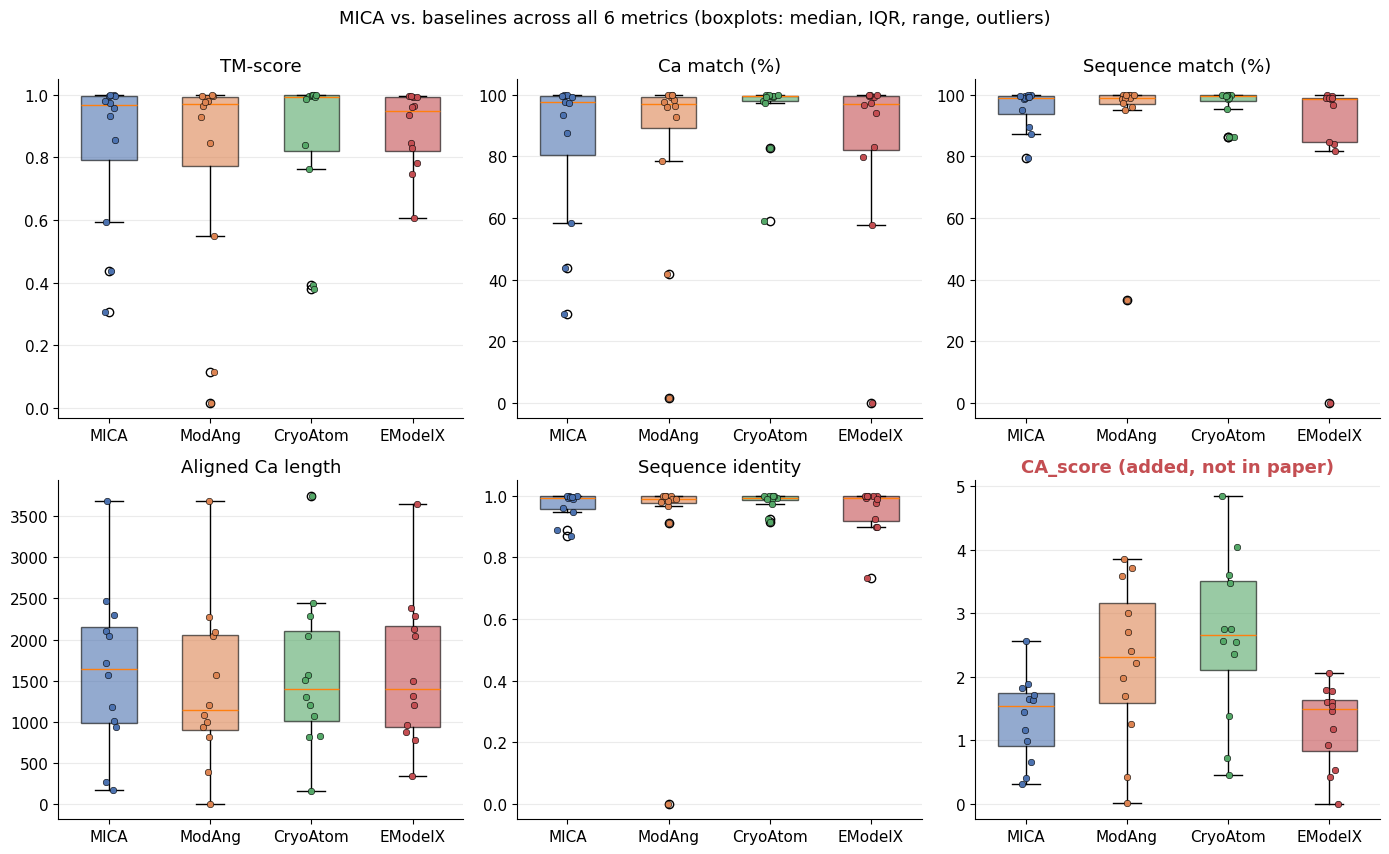

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
axes = axes.flatten()
palette = {"MICA": "#4C72B0", "ModelAngelo": "#DD8452", "CryoAtom": "#55A868", "EModelX": "#C44E52"}

panel_metrics = [
    ("TM_score_ref", "TM-score", False),
    ("Ca_match", "Ca match (%)", False),
    ("Seq_match_pct", "Sequence match (%)", False),
    ("Aligned_length", "Aligned Ca length", False),
    ("Seq_ID", "Sequence identity", False),
    ("CA_score", "CA_score (added, not in paper)", True),
]

for ax, (metric_col, title, is_added) in zip(axes, panel_metrics):
    data = [df.loc[df["method"] == m, metric_col].dropna().values for m in METHOD_ORDER]
    bp = ax.boxplot(data, labels=[DISPLAY_NAME[m] for m in METHOD_ORDER], patch_artist=True, showmeans=False, widths=0.55)
    for patch, m in zip(bp["boxes"], METHOD_ORDER):
        patch.set_facecolor(palette[m])
        patch.set_alpha(0.6)
    for i, m in enumerate(METHOD_ORDER, start=1):
        y = df.loc[df["method"] == m, metric_col].dropna().values
        x = rng.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, color=palette[m], edgecolor="black", linewidth=0.4, zorder=3, s=22)
    ax.set_title(title, fontweight="bold" if is_added else "normal",
                 color="#C44E52" if is_added else "black", fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

fig.suptitle("MICA vs. baselines across all 6 metrics (boxplots: median, IQR, range, outliers)",
              y=1.00, fontsize=13)
fig.tight_layout()
fig.savefig("../figures/all_metrics_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


## Save outputs

In [14]:
df.to_csv("../data/evaluation/evaluation_merged.csv", index=False)
summary_table.to_csv("../data/stats/summary_per_protein_tmscore.csv")
desc_table.to_csv("../data/stats/descriptive_stats_bootstrap_ci.csv", index=False)
friedman_df.to_csv("../data/stats/friedman_omnibus_results.csv", index=False)
for metric_col, posthoc in posthoc_results.items():
    posthoc.to_csv(f"../data/stats/posthoc_wilcoxon_{metric_col.lower()}.csv", index=False)
headline_table.to_csv("../data/stats/headline_comparison_paper_vs_added.csv", index=False)
strat_table.to_csv("../data/stats/stratified_coverage_comparison.csv", index=False)
dataset.to_csv("../data/stats/dataset_characteristics.csv", index=False)
print("Saved all outputs.")


Saved all outputs.


## CryoZeta (5th method) — separate comparison, n=10, 3 metrics

Kept deliberately separate from the 4-method/n=12 analysis above, not
merged in — two real differences prevent a like-for-like merge:

- **N=10, not 12**: `67233`/`73799` are excluded. Both are disclosed
  partial CryoZeta results (3/4 and 9/12 chains respectively — see
  `CRYOZETA_STATUS.md`), not comparable to a complete structure.
- **3 metrics, not 5/6**: only `TM_score_ref`, `Aligned_length`, and
  `Seq_ID` (all US-align-derived) are usable for CryoZeta. Its written
  `.cif` coordinates carry a residual rotation/translation offset from
  the true map frame that `phenix.chain_comparison`'s un-superposed
  scoring can't handle (7 of 10 entries score exactly zero) — US-align
  always superposes first, so it's unaffected. Full root-cause in
  `CRYOZETA_STATUS.md` finding #9.

In [15]:
CRYOZETA_ENTRIES = ["62164", "64568", "75023", "65506", "76934",
                    "71787", "71973", "70609", "64362", "79027"]
CZ_METHOD_ORDER = METHOD_ORDER + ["CryoZeta"]
CZ_METRICS = [
    ("TM_score_ref", "TM-score"),
    ("Aligned_length", "Aligned Ca length"),
    ("Seq_ID", "Sequence identity"),
]

cryozeta_usalign = pd.read_csv("../data/evaluation/evaluation_usalign_cryozeta.csv", dtype={"emdb_num": str})
cryozeta_usalign["method"] = "CryoZeta"

df_base_subset = df[df["emdb_num"].isin(CRYOZETA_ENTRIES)][
    ["emdb_num", "pdb_id", "method"] + [m[0] for m in CZ_METRICS]
].copy()
df_cz = pd.concat([
    df_base_subset,
    cryozeta_usalign[["emdb_num", "pdb_id", "method"] + [m[0] for m in CZ_METRICS]],
], ignore_index=True)
df_cz["method"] = pd.Categorical(df_cz["method"], categories=CZ_METHOD_ORDER, ordered=True)
df_cz = df_cz.sort_values(["emdb_num", "method"]).reset_index(drop=True)

assert df_cz.shape[0] == 10 * 5, f"expected 50 rows, got {df_cz.shape[0]}"
df_cz.head(10)

,emdb_num,pdb_id,method,TM_score_ref,Aligned_length,Seq_ID
0,62164,9k88,MICA,0.43855,172,0.948
1,62164,9k88,ModelAngelo,0.01613,6,0.000
2,62164,9k88,CryoAtom,0.39360,157,0.924
3,62164,9k88,EModelX,0.84670,340,0.897
4,62164,9k88,CryoZeta,0.97628,371,0.992
5,64362,9unu,MICA,0.99649,2294,0.997
6,64362,9unu,ModelAngelo,0.99049,2278,1.000
7,64362,9unu,CryoAtom,0.99668,2292,1.000
8,64362,9unu,EModelX,0.99331,2287,0.994
9,64362,9unu,CryoZeta,0.99891,2299,1.000


### Descriptive statistics (bootstrap median + 95% CI)

In [16]:
cz_desc_rows = []
for metric_col, metric_name in CZ_METRICS:
    for method in CZ_METHOD_ORDER:
        vals = df_cz.loc[df_cz["method"] == method, metric_col].dropna().values
        med, lo, hi = bootstrap_median_ci(vals)
        cz_desc_rows.append({"metric": metric_name, "method": method, "n": len(vals),
                              "median": round(med, 4), "ci_lo": round(lo, 4), "ci_hi": round(hi, 4)})
cz_desc_table = pd.DataFrame(cz_desc_rows)
cz_desc_table

,metric,method,n,median,ci_lo,ci_hi
0,TM-score,MICA,10,0.9690,0.6979,0.9969
1,TM-score,ModelAngelo,10,0.9718,0.7392,0.9957
2,TM-score,CryoAtom,10,0.9960,0.8402,0.9984
3,TM-score,EModelX,10,0.9476,0.8147,0.9940
4,TM-score,CryoZeta,10,0.9938,0.9765,0.9981
5,Aligned Ca length,MICA,10,1380.0000,640.5000,2039.0000
6,Aligned Ca length,ModelAngelo,10,1147.5000,909.0000,2039.0000
7,Aligned Ca length,CryoAtom,10,1359.5000,826.0000,2039.0000
8,Aligned Ca length,EModelX,10,1258.0000,872.0000,2039.0000
9,Aligned Ca length,CryoZeta,10,1389.5000,946.5000,2044.0000


### Omnibus test — Friedman across all 5 methods

In [17]:
cz_friedman_results = []
cz_wide_tables = {}
for metric_col, metric_name in CZ_METRICS:
    result, wide = friedman_with_effect_size(df_cz, metric_col, methods=CZ_METHOD_ORDER)
    result["metric"] = metric_name
    cz_friedman_results.append(result)
    cz_wide_tables[metric_col] = wide

cz_friedman_df = pd.DataFrame(cz_friedman_results)
cz_friedman_df

,metric,n_entries,k_methods,chi2,df,p_value,kendalls_w
0,TM-score,10,5,14.880,4,0.00496,0.372
1,Aligned Ca length,10,5,20.590,4,0.00038,0.515
2,Sequence identity,10,5,6.333,4,0.17560,0.158


### Post-hoc pairwise — Wilcoxon signed-rank, CryoZeta vs. each of the 4 baselines

In [18]:
cz_posthoc_results = {}
for metric_col, metric_name in CZ_METRICS:
    posthoc = pairwise_wilcoxon(cz_wide_tables[metric_col], reference="CryoZeta")
    cz_posthoc_results[metric_col] = posthoc
    print(f"=== {metric_name} ===")
    display(posthoc)
    print()

=== TM-score ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,CryoZeta vs MICA,4.0,0.01367,0.855,0.04102
1,CryoZeta vs ModelAngelo,8.0,0.04883,0.709,0.09766
2,CryoZeta vs CryoAtom,18.0,0.37500,0.345,0.37500
3,CryoZeta vs EModelX,0.0,0.00195,1.000,0.00781


=== Aligned Ca length ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,CryoZeta vs MICA,0.0,0.00391,1.000,0.01172
1,CryoZeta vs ModelAngelo,0.0,0.00195,1.000,0.00781
2,CryoZeta vs CryoAtom,3.0,0.07812,0.786,0.07812
3,CryoZeta vs EModelX,0.0,0.00391,1.000,0.01172


=== Sequence identity ===


,comparison,W_stat,p_raw,rank_biserial_r,p_holm
0,CryoZeta vs MICA,5.5,0.04297,0.756,0.17188
1,CryoZeta vs ModelAngelo,2.0,0.04688,0.857,0.17188
2,CryoZeta vs CryoAtom,3.0,0.07812,0.786,0.17188
3,CryoZeta vs EModelX,5.0,0.04297,0.778,0.17188


**Summary**: CryoZeta never loses significantly to any of the 4
baselines on any of the 3 usable metrics, and wins significantly
(Holm-corrected p<0.05) against 2-3 of them on TM-score and aligned
Cα length. Sequence identity shows the same directional trend (highest
median) but no pairwise difference survives correction — all 5 methods
are already near-ceiling (0.99+) at n=10.

### Figure — CryoZeta vs. 4 baselines, all 3 usable metrics

Same boxplot style as the 6-panel figure above (median, IQR, range,
individual points), CryoZeta highlighted the same way `CA_score` was
flagged there — not because it's an outlier, but to visually separate
"the method under special scrutiny" from the established 4.

/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/2162715640.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[cz_display_name[m] for m in CZ_METHOD_ORDER],
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/2162715640.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[cz_display_name[m] for m in CZ_METHOD_ORDER],
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75976/2162715640.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[cz_display_name[m] for m in CZ_METHOD_ORDER],


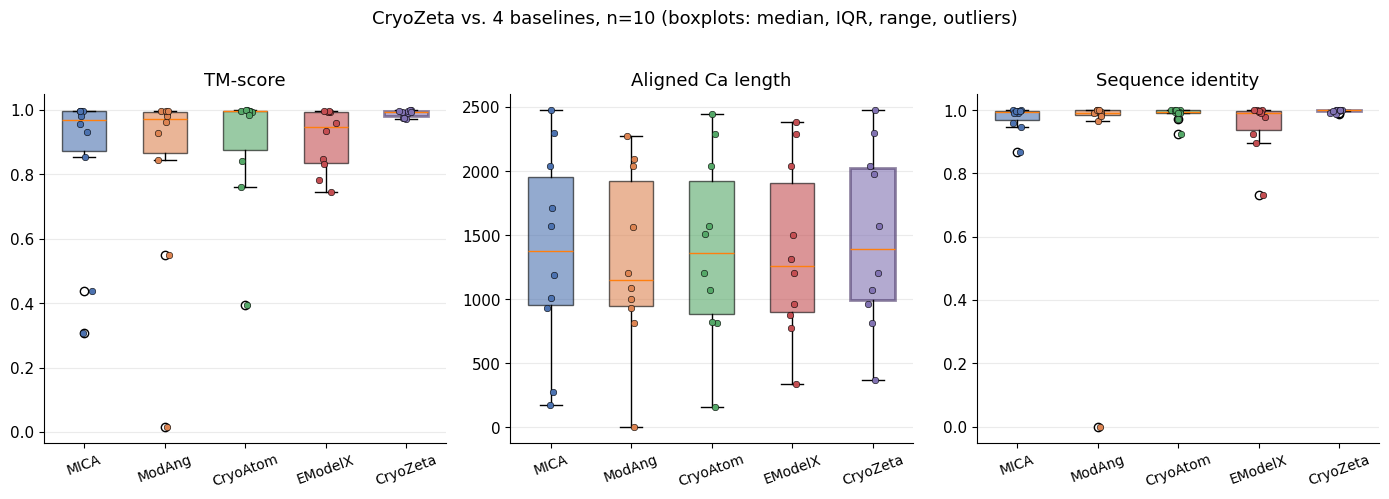

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
cz_palette = dict(palette)
cz_palette["CryoZeta"] = "#8172B2"

cz_panel_metrics = [
    ("TM_score_ref", "TM-score", False),
    ("Aligned_length", "Aligned Ca length", False),
    ("Seq_ID", "Sequence identity", False),
]
cz_display_name = dict(DISPLAY_NAME)
cz_display_name["CryoZeta"] = "CryoZeta"

for ax, (metric_col, title, _) in zip(axes, cz_panel_metrics):
    data = [df_cz.loc[df_cz["method"] == m, metric_col].dropna().values for m in CZ_METHOD_ORDER]
    bp = ax.boxplot(data, labels=[cz_display_name[m] for m in CZ_METHOD_ORDER],
                     patch_artist=True, showmeans=False, widths=0.55)
    for patch, m in zip(bp["boxes"], CZ_METHOD_ORDER):
        patch.set_facecolor(cz_palette[m])
        patch.set_alpha(0.6)
    for i, m in enumerate(CZ_METHOD_ORDER, start=1):
        y = df_cz.loc[df_cz["method"] == m, metric_col].dropna().values
        x = rng.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, color=cz_palette[m], edgecolor="black", linewidth=0.4, zorder=3, s=22)
    # highlight the CryoZeta box specifically
    cz_idx = CZ_METHOD_ORDER.index("CryoZeta")
    bp["boxes"][cz_idx].set_linewidth(2.0)
    bp["boxes"][cz_idx].set_edgecolor("#4B3869")
    ax.set_title(title, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", labelsize=10, rotation=20)
    ax.tick_params(axis="y", labelsize=11)

fig.suptitle("CryoZeta vs. 4 baselines, n=10 (boxplots: median, IQR, range, outliers)",
              y=1.03, fontsize=13)
fig.tight_layout()
fig.savefig("../figures/cryozeta_5method_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Save CryoZeta comparison outputs

In [20]:
df_cz.to_csv("../data/evaluation/evaluation_cryozeta_5method_merged.csv", index=False)
cz_desc_table.to_csv("../data/stats/descriptive_stats_5method_n10.csv", index=False)
cz_friedman_df.to_csv("../data/stats/friedman_5method_n10.csv", index=False)
pd.concat(cz_posthoc_results.values(), keys=cz_posthoc_results.keys()).to_csv(
    "../data/stats/posthoc_wilcoxon_5method_n10.csv"
)
print("Saved CryoZeta 5-method comparison outputs.")

Saved CryoZeta 5-method comparison outputs.
